<a href="https://colab.research.google.com/github/marcoskantor/Curso_Introduccion_Ingenieria_Datos/blob/main/tp1_ID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Disclaimer de uso de Inteligencia Artificial

**Herramienta utilizada:** DeepSeek — asistente conversacional basado en IA.

**Propósito del uso:**
- Apoyo en la comprensión del formato de los archivos GDELT 2.0 (separadores,
  campos y estructura del codebook).
- Orientación para organizar el flujo de trabajo: filtrado del `masterfilelist.txt`,
  descarga de archivos y cálculo de las métricas diarias solicitadas.
- Revisión de errores de sintaxis y ayuda para interpretar mensajes del entorno.

**Alcance:**
La IA se utilizó como herramienta de asistencia técnica durante el desarrollo
del trabajo. El código fue ejecutado y comprendido por el/la estudiante, y los
resultados obtenidos fueron revisados antes de su presentación. Las decisiones
metodológicas y la interpretación final de los datos son de autoría propia.

**Responsabilidad:** El contenido del notebook es de autoría propia, y la IA
cumplió un rol de apoyo y guía a lo largo del proceso.

In [46]:
import pandas as pd
import requests
from concurrent.futures import ThreadPoolExecutor
from io import BytesIO

In [47]:
COLUMNS = [
    "GlobalEventID", "Day", "MonthYear", "Year", "FractionDate",
    "Actor1Code", "Actor1Name", "Actor1CountryCode", "Actor1KnownGroupCode",
    "Actor1EthnicCode", "Actor1Religion1Code", "Actor1Religion2Code",
    "Actor1Type1Code", "Actor1Type2Code", "Actor1Type3Code",
    "Actor2Code", "Actor2Name", "Actor2CountryCode", "Actor2KnownGroupCode",
    "Actor2EthnicCode", "Actor2Religion1Code", "Actor2Religion2Code",
    "Actor2Type1Code", "Actor2Type2Code", "Actor2Type3Code",
    "IsRootEvent", "EventCode", "EventBaseCode", "EventRootCode",
    "QuadClass", "GoldsteinScale", "NumMentions", "NumSources", "NumArticles",
    "AvgTone",
    "Actor1Geo_Type", "Actor1Geo_FullName", "Actor1Geo_CountryCode",
    "Actor1Geo_ADM1Code", "Actor1Geo_ADM2Code", "Actor1Geo_Lat",
    "Actor1Geo_Long", "Actor1Geo_FeatureID",
    "Actor2Geo_Type", "Actor2Geo_FullName", "Actor2Geo_CountryCode",
    "Actor2Geo_ADM1Code", "Actor2Geo_ADM2Code", "Actor2Geo_Lat",
    "Actor2Geo_Long", "Actor2Geo_FeatureID",
    "ActionGeo_Type", "ActionGeo_FullName", "ActionGeo_CountryCode",
    "ActionGeo_ADM1Code", "ActionGeo_ADM2Code", "ActionGeo_Lat",
    "ActionGeo_Long", "ActionGeo_FeatureID",
    "DATEADDED", "SOURCEURL"
]

In [48]:
url_master = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

master = pd.read_csv(
    url_master,
    sep=" ",
    header=None,
    names=["size", "hash", "url"],
    low_memory=False        # ← fix del DtypeWarning
)

# Rango: 02/09/2026 al 09/09/2026
fecha_ini = "20260902"
fecha_fin = "20260909"

urls = master[
    master["url"].str.endswith(".export.CSV.zip") &
    master["url"].str.extract(r"(\d{8})")[0].between(fecha_ini, fecha_fin)
]["url"].tolist()

print(f"Archivos a descargar: {len(urls)}")
for u in urls[:3]:
    print(" ", u)

Archivos a descargar: 768
  http://data.gdeltproject.org/gdeltv2/20260902000000.export.CSV.zip
  http://data.gdeltproject.org/gdeltv2/20260902001500.export.CSV.zip
  http://data.gdeltproject.org/gdeltv2/20260902003000.export.CSV.zip


In [49]:
def leer(url):
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    return pd.read_csv(
        BytesIO(r.content),
        sep="\t",
        header=None,
        names=COLUMNS,
        compression="zip",
        low_memory=False,
        quoting=3   # evita problemas con comillas dentro de URLs
    )

with ThreadPoolExecutor(max_workers=10) as ex:
    dfs = list(ex.map(leer, urls))

df = pd.concat(dfs, ignore_index=True)
print("Eventos totales:", len(df))
df.head(2)

Eventos totales: 791519


,GlobalEventID,Day,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1321003469,20250902,202509,2025,2025.663,NaN,NaN,NaN,NaN,NaN,...,1,Australia,AS,AS,NaN,-25.0000,135.000,AS,20260902000000,https://home.nzcity.co.nz/news/article.aspx?id...
1,1321003470,20250902,202509,2025,2025.663,AUS,QUEENSLAND,AUS,NaN,NaN,...,4,"Ryan Park, New South Wales, Australia",AS,AS02,5096,-29.4485,153.201,11357250,20260902000000,https://www.queanbeyanage.com.au/story/9341983...


In [50]:
# Convertir Day (YYYYMMDD) a fecha
df["fecha"] = pd.to_datetime(df["Day"].astype(str), format="%Y%m%d").dt.date

# Quedarnos SOLO con eventos ocurridos entre 02/09 y 09/09/2026
mask = (df["fecha"] >= pd.to_datetime("2026-09-02").date()) & \
       (df["fecha"] <= pd.to_datetime("2026-09-09").date())

df_filtrado = df[mask]

# Agrupar por día
resumen = (
    df_filtrado.groupby("fecha")
      .agg(
          Cantidad_Eventos   = ("GlobalEventID", "count"),
          Promedio_Articulos = ("NumArticles", "mean"),
          Promedio_Fuentes   = ("NumSources",  "mean"),
      )
      .round(3)
      .reset_index()
)

resumen

,fecha,Cantidad_Eventos,Promedio_Articulos,Promedio_Fuentes
0,2026-09-02,118700,4.645,1.048
1,2026-09-03,114819,4.638,1.045
2,2026-09-04,105007,4.696,1.046
3,2026-09-05,65800,4.652,1.040
4,2026-09-06,59604,4.579,1.044
5,2026-09-07,84639,4.684,1.039
6,2026-09-08,112860,4.611,1.048
7,2026-09-09,116772,4.632,1.042


# TP1 — Ingesta y exploración de datos GDELT 2.0

## Decisión de acceso a los datos
Se utilizó `masterfilelist.txt` porque es la lista oficial que GDELT publica y actualiza cada 15 minutos, y contiene las URLs de todos los archivos históricos. Filtrar por el timestamp `YYYYMMDD` del nombre del archivo es la forma más confiable de obtener exactamente los archivos de un rango de fechas sin adivinar nombres.

Los ~96 archivos diarios (4 por hora × 24 hs) se descargaron en **paralelo** con `ThreadPoolExecutor`, ya que son independientes entre sí y el servidor de GDELT soporta múltiples conexiones. Se leyeron **directamente desde el ZIP** (`compression="zip"`) para ahorrar espacio en disco y evitar pasos innecesarios de descompresión.

## Formato de los archivos
Los archivos `.export.CSV.zip` son en realidad **tab-delimited** (según el Event Codebook V2.0), aunque tengan extensión `.csv`. Por eso se leen con `sep="\t"`.

## Cálculo de las métricas
- **Cantidad de eventos**: `count` de `GlobalEventID`.
- **Promedio de artículos por evento**: media de `NumArticles` (total de artículos que mencionan el evento).
- **Promedio de fuentes por evento**: media de `NumSources` (total de fuentes distintas que lo reportan).

Se agrupó por el campo `Day` (fecha en que ocurrió el evento) y se filtró al rango 02/09–09/09/2026. Aparecen eventos con fechas anteriores en el dataset crudo porque GDELT registra en cada archivo menciones a eventos históricos citados por las noticias actuales; esos casos se excluyeron del resultado final.

#Graficos Extras (sin ia)

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

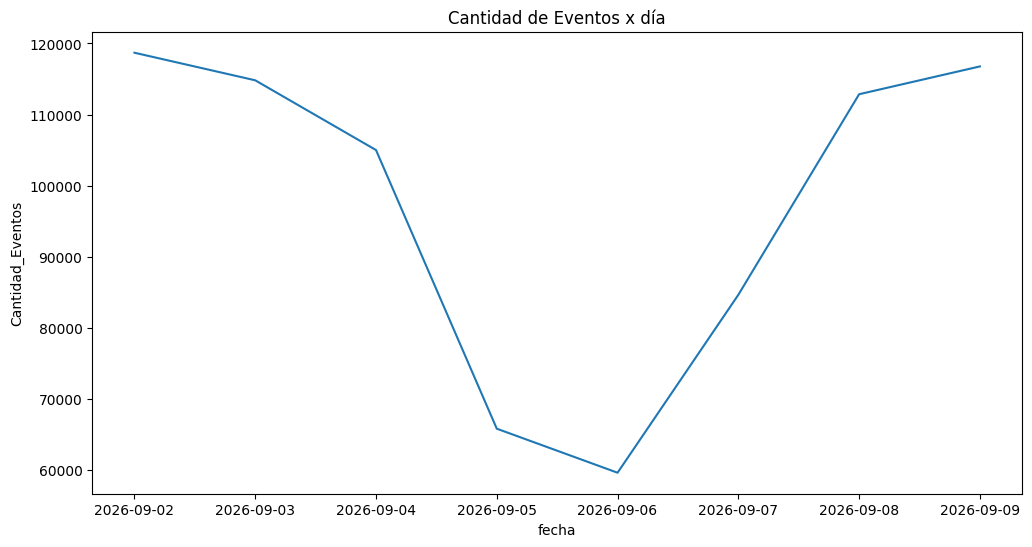

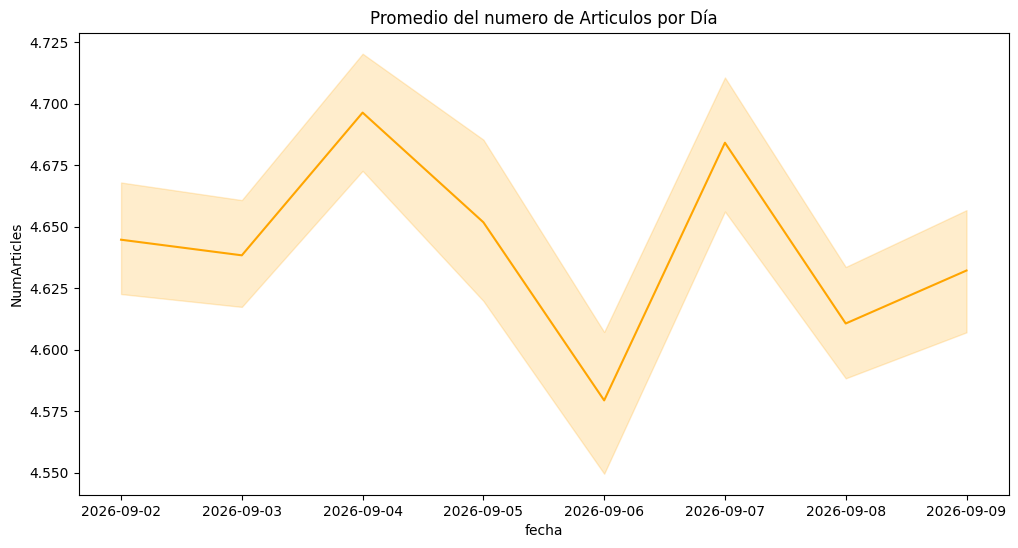

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

In [52]:
plt.figure(figsize=(12,6))
sns.lineplot(data=resumen,x="fecha",y="Cantidad_Eventos")
plt.title("Cantidad de Eventos x día")
plt.show()


plt.figure(figsize=(12,6))
sns.lineplot(data=df_filtrado, x="fecha", y="NumArticles",color="orange")
plt.title("Promedio del numero de Articulos por Día")
plt.show()

plt.figure(figsize=(12,6))


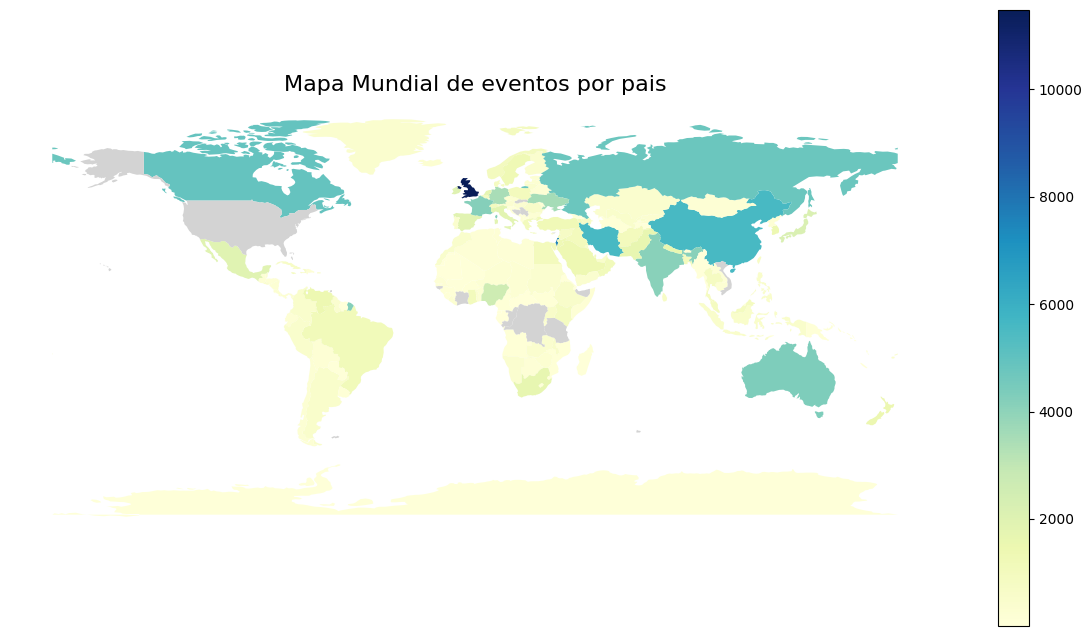

In [53]:
import geopandas as gpd


url = "https://raw.githubusercontent.com/python-visualization/folium/main/examples/data/world-countries.json"
world = gpd.read_file(url)

#Resumen por pais:
# Agrupar por día
resumen2 = (
    df_filtrado.groupby("ActionGeo_FullName")
      .agg(
          Cantidad_Eventos   = ("GlobalEventID", "count"),
          Promedio_Articulos = ("NumArticles", "mean"),
          Promedio_Fuentes   = ("NumSources",  "mean"),
      )
      .round(3)
      .reset_index()
)

merged = world.merge(resumen2, left_on='name', right_on='ActionGeo_FullName', how='left')

fig, ax = plt.subplots(1, 1, figsize=(15, 8))
merged.plot(
    column='Cantidad_Eventos',
    ax=ax,
    legend=True,
    cmap='YlGnBu',
    missing_kwds={'color': 'lightgrey', 'label': 'Sin datos'}
)

ax.set_title('Mapa Mundial de eventos por pais', fontsize=16)
ax.axis('off')
plt.show()